<a href="https://colab.research.google.com/github/masrik-dev/food-image-recognition/blob/main/Food_Vision_Mini_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🍔👀 Food Vision Mini Classifier**

## **Introduction**

This project focuses on developing a machine learning model for classifying types of food from photographs. The goal is to build a robust image classification system capable of accurately identifying different food categories based on visual features. To train and evaluate the model, we utilized Food-101 dataset, a comprehensive collection of food images sourced from Kaggle. This dataset comprises 101 distinct classes of food, providing a diverse and challenging benchmark for training and testing the model's performance.
> **Due to our computational limitation we will use only 10% of it's data**

Original Food101 paper: https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf



## Check GPU and TensorFlow version

In [1]:
# Are we using a GPU?
# If not, and you're in Google Colab, go to Runtime -> Change runtime type -> Hardware accelerator -> GPU
# !nvidia-smi

In [2]:
# Check TensorFlow version
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Add timestamp
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

TensorFlow version: 2.20.0
Notebook last run (end-to-end): 2026-05-11 18:06:22.170559


## Import `helper_function.py` file

Import `helper_function.py`, which includes utility functions such as:
`load_and_prep_image`, `make_confusion_matrix`, `pred_and_plot`, `plot_loss_curves`, and `calculate_results`.

These will assist with model evaluation, data preprocessing, and result visualization.

In [3]:
!wget https://raw.githubusercontent.com/masrik-dev/food-image-recognition/refs/heads/main/helper_function.py

--2026-05-11 18:06:22--  https://raw.githubusercontent.com/masrik-dev/food-image-recognition/refs/heads/main/helper_function.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9907 (9.7K) [text/plain]
Saving to: ‘helper_function.py’

helper_function.py  100%[===================>]   9.67K  --.-KB/s    in 0s      

2026-05-11 18:06:22 (93.9 MB/s) - ‘helper_function.py’ saved [9907/9907]



In [4]:
import helper_function
dir(helper_function)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'accuracy_score',
 'calculate_results',
 'compare_historys',
 'confusion_matrix',
 'itertools',
 'load_and_prep_image',
 'make_confusion_matrix',
 'np',
 'os',
 'plot_loss_curves',
 'plt',
 'precision_recall_fscore_support',
 'pred_and_plot',
 'tf',
 'unzip_data',
 'walk_through_dir',
 'zipfile']

In [5]:
# Import series of helper functions for the notebook
from helper_function import load_and_prep_image, make_confusion_matrix, pred_and_plot, plot_loss_curves, calculate_results, unzip_data, compare_historys, walk_through_dir

## 101 Food Classes: working with 10% data

Our goal is to beat the original Food101 paper with 10% of the training data.

We are using data from Food101 dataset and preprocesed data using [image_data_modification](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/image_data_modification.ipynb) code.

In [6]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
unzip_data("101_food_classes_10_percent.zip")

train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

--2026-05-11 18:06:22--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.141.207, 142.251.2.207, 74.125.137.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.141.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G   192MB/s    in 11s     

2026-05-11 18:06:33 (147 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [7]:
# How many images/classes are there?
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/ravioli'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/paella'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/macarons'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/guacamole'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/cheese_plate'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/macaroni_and_cheese'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/spaghetti_carbonara'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/beef_tartare'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/panna_cotta'.
There are 0 directories and 250 image

## **Data Pipeline**

In [8]:
# Setup data inputs (or make a image into a tensor or numbers)
import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False) #don't shuffle test data for prediction analysis


Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [9]:
class_names = train_data_all_10_percent.class_names
print(class_names[:10])

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [10]:
num_classes = len(class_names)
print(num_classes)

101


In [11]:
train_size = len(train_data_all_10_percent)
test_size = len(test_data)

print(train_size, test_size)

237 790


In [12]:
ds_info = {
    "num_classes": len(class_names),
    "class_names": class_names,
    "image_size": IMG_SIZE
}

ds_info

{'num_classes': 101,
 'class_names': ['apple_pie',
  'baby_back_ribs',
  'baklava',
  'beef_carpaccio',
  'beef_tartare',
  'beet_salad',
  'beignets',
  'bibimbap',
  'bread_pudding',
  'breakfast_burrito',
  'bruschetta',
  'caesar_salad',
  'cannoli',
  'caprese_salad',
  'carrot_cake',
  'ceviche',
  'cheese_plate',
  'cheesecake',
  'chicken_curry',
  'chicken_quesadilla',
  'chicken_wings',
  'chocolate_cake',
  'chocolate_mousse',
  'churros',
  'clam_chowder',
  'club_sandwich',
  'crab_cakes',
  'creme_brulee',
  'croque_madame',
  'cup_cakes',
  'deviled_eggs',
  'donuts',
  'dumplings',
  'edamame',
  'eggs_benedict',
  'escargots',
  'falafel',
  'filet_mignon',
  'fish_and_chips',
  'foie_gras',
  'french_fries',
  'french_onion_soup',
  'french_toast',
  'fried_calamari',
  'fried_rice',
  'frozen_yogurt',
  'garlic_bread',
  'gnocchi',
  'greek_salad',
  'grilled_cheese_sandwich',
  'grilled_salmon',
  'guacamole',
  'gyoza',
  'hamburger',
  'hot_and_sour_soup',
  'hot_

In [13]:
# Take one batch
train_one_batch = train_data_all_10_percent.take(1)

In [14]:
# Inspect one image + label
for images, labels in train_one_batch:
    image = images[0]   # first image in batch
    label = labels[0]   # first label

    print(f"""
    Image shape: {image.shape}
    Image dtype: {image.dtype}
    Label (one-hot): {label}
    Label index: {tf.argmax(label)}
    Class name: {class_names[tf.argmax(label)]}
    """)


    Image shape: (224, 224, 3)
    Image dtype: <dtype: 'float32'>
    Label (one-hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]
    Label index: 17
    Class name: cheesecake
    


In [15]:
# Min & Max values
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=float32, numpy=0.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=255.0>)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

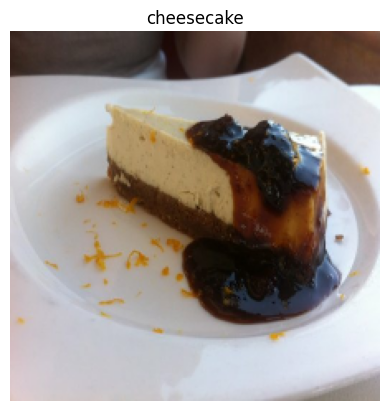

In [16]:
# Plot image
import matplotlib.pyplot as plt

plt.imshow(image.numpy().astype("uint8"))
plt.title(class_names[tf.argmax(label)])
plt.axis(False)

In [17]:
# Preprocessing function
def preprocess_img(image, label, img_shape=224):
    image = tf.image.resize(image, [img_shape, img_shape])
    image = tf.cast(image, tf.float32) / 255.0  # normalize
    return image, label

In [18]:
# Test preprocessing
preprocessed_img, _ = preprocess_img(image, label)

print(f"Before: {image.shape}, {image.dtype}")
print(f"After: {preprocessed_img.shape}, {preprocessed_img.dtype}")

Before: (224, 224, 3), <dtype: 'float32'>
After: (224, 224, 3), <dtype: 'float32'>


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

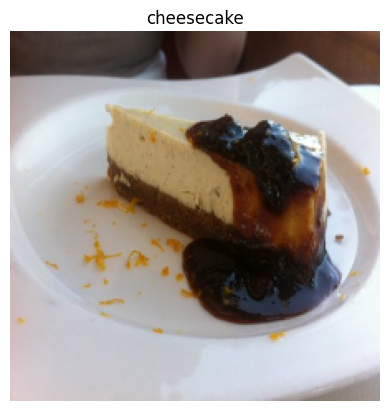

In [19]:
# Plot preprocessed
plt.imshow(preprocessed_img)
plt.title(class_names[tf.argmax(label)])
plt.axis(False)

In [20]:
# Apply preprocessing
train_data = train_data_all_10_percent.map(
    preprocess_img,
    num_parallel_calls=tf.data.AUTOTUNE
).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

test_data = test_data.map(
    preprocess_img,
    num_parallel_calls=tf.data.AUTOTUNE
).cache().prefetch(tf.data.AUTOTUNE)

In [21]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>)

In [22]:
# Let's figure out the image batch shape, and labels batch shape
for images, lbls in train_data.take(1):
    print("Image batch shape:", images.shape)
    print("Labels batch shape:", lbls.shape)

Image batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 101)


## Setup mixed precision training

In [23]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy="mixed_float16")

In [24]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Train a model with transfer learning on 10% of 101 food classes

Here are the steps we're going to take:
* Create a ModelCheckpoint callback
* Create a data augmentation layer to build data augmentation right into the model
* Build a headless (no top layers) functional EfficientNetB0 backboned-model (we'll create our own output layer)
* Compile our model
* Feature extract for 5 full passes (5 epochs on the train dataset and validat on 15% of the test data, to save epoch time)

In [25]:
# Create a ModelCheckpoint callback
checkpoint_path = "101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)

In [26]:
# Create data augmentation layer to incorporate it right into the model
from tensorflow.keras import layers, Sequential

# Setup data augmentation
data_augmentation = Sequential([
    layers.Resizing(224, 224),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
    #layers.Rescaling(1./255)
], name="data_augmentation")

## **Model_1**

In [27]:
# Setup the base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer")
x = data_augmentation(inputs, training=True) # augment images (only happens during training phase)
x = base_model(x, training=False) # put the base model in inference mode so weights which need to stay frozen, stay  frozen
x = layers.GlobalAveragePooling2D(name="global_average_pooling_layer")(x)
outputs = layers.Dense(len(class_names), activation="softmax", name="output_layer")(x)
model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
# Get a summary of model we've created
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling_layer    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
# Compile
with tf.device('/GPU:0'):
  model.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data,
                                           epochs=5,
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)), # validate only 15% of test data
                                           callbacks=[checkpoint_callback])


Epoch 1/5
  2/237 ━━━━━━━━━━━━━━━━━━━━ 1:12:04 18s/step - accuracy: 0.0312 - loss: 4.6581

In [ ]:
# Evaluate on the whole test dataset
feature_extraction_results = model.evaluate(test_data)
feature_extraction_results

In [ ]:
plot_loss_curves(history_all_classes_10_percent)

## Fine-tuning

In [ ]:
# Unfreeze last 5 layers in the base model
base_model.trainable = False

for layer in base_model.layers[-5:]:
  layer.trainable = True

In [ ]:
# Recompile model with lower learning rate: it's typically best practice to lower the learning rate when fine-tuning
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

In [ ]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

In [ ]:
# Check which layers are trainable in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
  print(layer_number, layer.name, layer.trainable)

In [ ]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10  # it is the total epochs = feature extraction epochs 5 + 5 fine tune epochs

# Fine-tune our model
history_all_classes_10_percent_fine_tune = model.fit(train_data,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1])


In [ ]:
# Save fine-tuning history
np.save(
    "histories/efficientnetb0_finetune_history.npy",
    history_all_classes_10_percent_fine_tune.history
)

print("Fine-tuning history saved successfully!")

In [ ]:
# Evaluate on the whole test dataset
all_classes_10_percent_fine_tune_results = model.evaluate(test_data)
all_classes_10_percent_fine_tune_results

In [ ]:
# Compare the histories of feature extraction model with fine-tunining model
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Making predictions with model

In [ ]:
# Make predictions with model
pred_probs = model.predict(test_data, verbose=1)

In [ ]:
# How many predictions are there, and what is the shape of the predictions
len(pred_probs), pred_probs.shape

In [ ]:
# How do they look
pred_probs[:10]

In [ ]:
# Get the class predictions of each label
pred_classes = pred_probs.argmax(axis=1)
pred_classes[:10]

To retrieve the test dataset labels, unravel the `test_data` (a `tf.data.Dataset` object) by using the `unbatch()` method.

In [ ]:
y_labels = []
for images, labels in test_data.unbatch():
  y_labels.append(labels.numpy().argmax())
y_labels[:10]

In [ ]:
# Get the class names
class_names[:10]

### Confusion matrix

In [ ]:
# Plot the confusion matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

## Saving and loading our model

To use it in an external application, we'll need to save it and export it somewhere.

In [ ]:
import os

# Make sure the 'models' folder exists
os.makedirs("models", exist_ok=True)
# Now save the model
model.save("models/food_vision_model_1.keras")

In [ ]:
# Load and evaluate saved model
loaded_model_1 = tf.keras.models.load_model("models/food_vision_model_1.keras")

In [ ]:
# Evaluate loaded model and compare performance to pre-saved model
loaded_model_results_1 = loaded_model_1.evaluate(test_data)
loaded_model_results_1

In [ ]:
# The results from our loaded model (above) should be very similar to the results below
all_classes_10_percent_fine_tune_results

## Rebuild a model (Model_2)

What to do:

1. Try EfficientNetB1 instead of EfficientNetB0
2. Enable Fine-Tuning (unfreeze last 10 layers of EfficientNetB1)
3. Experiment with Batch Normalization
4. Add More Fully Connected (Dense) Layers
5. Experiment with Batch Normalization
6. Decrease the learning rate of optimizer
7. Change `steps_per_epoch` and `validation_steps` in model fitting.

In [ ]:
# Model checkpoint and mixed precision training
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import mixed_precision

# Define the checkpoint path
checkpoint_path = "model_checkpoints/model_2/cp.weights.h5"
# Create a model checkpoint callback
model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True
)
# Enable mixed precision
mixed_precision.set_global_policy(policy="mixed_float16")

## Build mode_2

In [ ]:
from tensorflow.keras import layers

# Switch to EfficientNetB1
base_model = tf.keras.applications.EfficientNetB1(include_top=False)

# Unfreeze the last 10 layers (fewer layers for finetuning to reduce training time)
for layer in base_model.layers[-10:]:
  layer.trainable = True

inputs = layers.Input(shape=(224, 224, 3), name="input_layer")

# EfficientNet and additional layers
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="avg_pool")(x) # Efficient feature extraction
x = layers.BatchNormalization(name="batch_norm")(x)
x = layers.Dense(128, activation="relu", name="dense_layer_1")(x) # Reduced to 128 neurons
x = layers.Dropout(0.2, name="dropout_1")(x) # Lower dropout to reduce computation
x = layers.Dense(len(class_names), name="output_dense")(x) # Final layer for classification
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax")(x)

# Compile the model
model_2 = tf.keras.Model(inputs, outputs)

# Use mixed precision optimizer
optimizer = mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=0.0001))
model_2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

In [ ]:
# Plot the tribid model
from keras.utils import plot_model
plot_model(model_2, show_shapes=True, dpi=100)

## Fit the model_2

In [ ]:
history_model_2 = model_2.fit(train_data,
                              epochs=5,
                              steps_per_epoch=int(0.15*len(train_data)),
                              validation_data=test_data,
                              validation_steps=int(0.15*len(test_data)),
                              callbacks=[model_checkpoint])

In [ ]:
# Save fine-tuning history
np.save(
    "histories/efficientnetb1_history.npy",
    history_model_2.history
)

print("Model_2 history saved successfully!")

In [ ]:
plot_loss_curves(history_model_2)

In [ ]:
model_2.evaluate(test_data)

In [ ]:
# Make predictions with model
pred_probs_2 = model_2.predict(test_data, verbose=1)

In [ ]:
# How many predictions are there, and what is the shape of the predictions
len(pred_probs_2), pred_probs_2.shape

In [ ]:
# How do they look
pred_probs_2[:10]

In [ ]:
# Get the class predictions of each label
pred_classes_2 = pred_probs_2.argmax(axis=1)
pred_classes_2[:10]

### Confusion matrix of model_2

In [ ]:
# Plot the confusion matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes_2,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

In [ ]:
# Save Model_2
model_2.save("models/food_vision_model_2.keras")

In [ ]:
# Load Model_2
loaded_model_2 = tf.keras.models.load_model("models/food_vision_model_2.keras")

## Model_3
Creating and testing **ResNet50** TensorFlow Hub Feature Extraction model

In [ ]:
# Let's import the following two models
resnet_url = "https://www.kaggle.com/models/tensorflow/resnet-50/TensorFlow2/classification/1"
mobilenet_url = "https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/100-224-feature-vector/1"

**Custom wrapper layer so Sequential accepts it**: Use the code from [stackoverflow](https://stackoverflow.com/questions/78530756/error-only-instances-of-keras-layer-can-be-added-to-a-sequential-model) to solve the problem of Sequential accepting the layers from `resnet_url`

In [ ]:
# Import the dependencies
from tensorflow.keras import layers
import tensorflow_hub as hub
import tf_keras as keras
IMAGE_SHAPE = (224, 224)

In [ ]:
# Let's make a create_model() function to create a model from a URL
def create_model(model_url, num_classes):
  """
  Takes a URL and creates a Keras Sequential model with it
  Arguments:
    model_url(str) : Link to the model
    num_classes(int) : Number of output neurons in the output layer, should be equal to the number of target classes, default = 10
  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor layer and Dense output layer with num_classes output neurons
  """
  # Downlaod the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                            trainable = False,  #False in order to freeze the already learnt patterns.
                                            name = "feature_extraction_layer",
                                            input_shape = IMAGE_SHAPE + (3, ))

  # Custom wrapper layer so Sequential accepts it
  # class ResNetV2FeatureLayer(tf.keras.layers.Layer):
  #   def call(self, inputs):
  #     return feature_extraction_layer(inputs)

  # Create our own model
  # model = keras.Sequential([
  #     tf.keras.Input(shape=IMAGE_SHAPE+(3,), name="input_image"),
  #     ResNetV2FeatureLayer(), # Wrapped feature extractor
  #     layers.Dense(num_classes, activation = "softmax", name= "output_layer")
  # ])
  model = keras.Sequential([
      feature_extractor_layer,
      keras.layers.Dense(num_classes, activation="softmax", name="output_layer")
  ])

  return model

In [ ]:
# Create ResNet model as model_3
model_3 = create_model(resnet_url,
                       num_classes = train_data.num_classes)

In [ ]:
# Compile our resnet model
model_3.compile(loss="categorical_crossentropy",
                     optimizer=keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [ ]:
history_model_3 = model_3.fit(train_data,
                              epochs=5,
                              steps_per_epoch=int(0.15*len(train_data)),
                              validation_data=test_data,
                              validation_steps=int(0.15*len(test_data)),
                              callbacks=[model_checkpoint])

In [ ]:
# Save fine-tuning history
np.save(
    "histories/resnet50_history.npy",
    history_model_3.history
)

print("ResNet50 history saved successfully!")

In [ ]:
model_3.summary()

In [ ]:
plot_loss_curves(history_model_3)

In [ ]:
model_3.evaluate(test_data)

In [ ]:
# Make predictions with model
pred_probs_3 = model_3.predict(test_data, verbose=1)

In [ ]:
# How many predictions are there, and what is the shape of the predictions
len(pred_probs_3), pred_probs_3.shape

In [ ]:
# How do they look
pred_probs_3[:10]

In [ ]:
# Get the class predictions of each label
pred_classes_3 = pred_probs_3.argmax(axis=1)
pred_classes_3[:10]

### Confusion matrix of model_3

In [ ]:
# Plot the confusion matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes_3,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

In [ ]:
# Save Model_3
model_3.save("models/food_vision_model_3.keras")

In [ ]:
# Load Model_3
loaded_model_3 = tf.keras.models.load_model("models/food_vision_model_3.keras")

## Model_4
Creating and testing **MobileNet** TensorFlow Hub Feature Extraction model

In [ ]:
# Create MobileNet feature extractor model
model_4 = create_model(model_url=mobilenet_url,
                               num_classes=train_data.num_classes)

# Compile MobileNet model
model_4.compile(loss="categorical_crossentropy",
                        optimizer=keras.optimizers.Adam(),
                        metrics=["accuracy"])

In [ ]:
history_model_4 = model_4.fit(train_data,
                              epochs=5,
                              steps_per_epoch=int(0.15*len(train_data)),
                              validation_data=test_data,
                              validation_steps=int(0.15*len(test_data)),
                              callbacks=[model_checkpoint])

In [ ]:
# Save fine-tuning history
np.save(
    "histories/mobilenet_history.npy",
    history_model_4.history
)

print("MobileNet history saved successfully!")

In [ ]:
model_4.summary()

In [ ]:
plot_loss_curves(history_model_4)

In [ ]:
model_4.evaluate(test_data)

In [ ]:
# Make predictions with model
pred_probs_4 = model_4.predict(test_data, verbose=1)

In [ ]:
# How many predictions are there, and what is the shape of the predictions
len(pred_probs_4), pred_probs_4.shape

In [ ]:
# How do they look
pred_probs_4[:10]

In [ ]:
# Get the class predictions of each label
pred_classes_4 = pred_probs_4.argmax(axis=1)
pred_classes_4[:10]

### Confusion matrix of model_4

In [ ]:
# Plot the confusion matrix
make_confusion_matrix(y_true=y_labels,
                      y_pred=pred_classes_4,
                      classes=class_names,
                      figsize=(100, 100),
                      text_size=20,
                      norm=False,
                      savefig=True)

In [ ]:
# Save Model_4
model_4.save("models/food_vision_model_4.keras")

In [ ]:
# Load Model_4
loaded_model_4 = tf.keras.models.load_model("models/food_vision_model_4.keras")

## Compare the results of 4 models on new data

### Upload photos from local file to test model

In [ ]:
from google.colab import files

# This will open a file picker
uploaded = files.upload()

In [ ]:
import zipfile

# Extract the uploaded zip
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("uploaded_photos")

print("Extracted photos to 'uploaded_photos/'")

In [ ]:
import tensorflow as tf
import os

# Make test_photos folder
os.makedirs("test_photos", exist_ok=True)

# Go through uploaded images, resize, and save as JPG
for i, filename in enumerate(os.listdir("uploaded_photos")):
  if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
    img = tf.io.read_files(os.path.join("uploaded_photos", filename))
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [224, 224])  # resize for model
    img_bytes = tf.io.encode_jpeg(tf.cast(img, tf.uint8))
    tf.io.write_file(f"test_photos/img_{i}.jpg", img_bytes)

print("Saved all uploaded images into 'test_photos/")

In [ ]:
# Make photo path to push it in the testing
test_photo_paths = [os.path.join("test_photos", fname) for fname in os.listdir("test_photos")]

### Compare models with uploaded photos

In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model_paths = {
    "EfficientNetB0": "models/food_vision_model_1.keras",
    "EfficientNetB1": "models/food_vision_model_2.keras",
    "ResNet50": "models/food_vision_model_3.keras",
    "MobileNet": "models/food_vision_model_4.keras"
}

test_photos_dir = "test_photos"

label_encoder = LabelEncoder()
label_encoder.classes_ = np.load("models/label_classes.npy")

def preprocess_image(image_path, img_size=(224, 224), model_path=None):
  img = image.load_img(image_path, target_size=img_size)
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, axis=0)
  if model_path in ["models/food_vision_model_3.keras", "models/food_vision_model_4.keras"]:  # EfficientNetBX makes scaling automatically
    img_array = img_array / 255.
  return img_array

def predict_food_type_with_confidence(model, model_path, image_path):
  img_array = preprocess_image(image_path, model_path=model_path)
  predictions = model.predict(img_array, verbose=0)
  predicted_label_idx = np.argmax(predictions, axis=1)[0]
  confidence = predictions[0][predicted_label_idx]
  food_type = label_encoder.inverse_transform([predicted_label_idx])
  return food_type[0], confidence

models = {name: load_model(path, compile=False) for name, path in model_paths.items()}

test_photo_paths = [os.path.join(test_photos_dir, fname) for fname in os.listdir(test_photos_dir)]

fig, axes = plt.subplots(len(models), len(test_photo_paths), figsize=(20, 10))
fig.suptitle("Model Predictions Comparison", fontsize=16)

for j, model_name in enumerate(models.keys()):
  axes[0, j].set_title(model_name, fontsize=12)

for j, (model_name, model_paths) in enumerate(model_paths.items()):
  for i, photo_path in enumerate(test_photo_paths):
    predicted_food, confidence = predict_food_type_with_confidence(models[model_name], model_path, photo_path)
    img = image.load_img(photo_path)
    axes[j, i].imshow(img)
    axes[j, i].axis('off')
    axes[j, i].set_title(f"{predicted_food} ({confidence:.2%})", fontsize=12)
plt.show()

## Compare data of the 4 models and choose the best one

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
history_paths = {
    "EfficientNetB0": "histories/efficientnetb0_finetune_history.npy",
    "EfficientNetB1": "histories/efficientnetb1_history.npy",
    "ResNet50": "histories/resnet50_history.npy",
    "MobileNet": "histories/mobilenet_history.npy"
}

In [ ]:
metrics_all_runs = {}

for model_name, path in history_paths.items():
    history_dict = np.load(path, allow_pickle=True).item()

    df = pd.DataFrame(history_dict)
    df["epoch"] = range(len(df))

    metrics_all_runs[model_name] = df

In [ ]:
for run_name, df in metrics_all_runs.items():
    print(f"\n📊 Model: {run_name}")
    display(df[["epoch", "accuracy", "val_accuracy", "loss", "val_loss"]])

### Plot comparison charts

In [ ]:
plt.figure(figsize=(14, 10))

# Training Accuracy
plt.subplot(2, 2, 1)
for run_name, df in metrics_all_runs.items():
    plt.plot(df["epoch"], df["accuracy"], label=run_name)

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# Validation Accuracy
plt.subplot(2, 2, 2)
for run_name, df in metrics_all_runs.items():
    plt.plot(df["epoch"], df["val_accuracy"], label=run_name)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()


# Training Loss
plt.subplot(2, 2, 3)
for run_name, df in metrics_all_runs.items():
    plt.plot(df["epoch"], df["loss"], label=run_name)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


# Validation Loss
plt.subplot(2, 2, 4)
for run_name, df in metrics_all_runs.items():
    plt.plot(df["epoch"], df["val_loss"], label=run_name)

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Automatically select best model

In [ ]:
best_model = None
best_accuracy = 0

for run_name, df in metrics_all_runs.items():
    max_val_acc = df["val_accuracy"].max()

    print(f"{run_name}: {max_val_acc:.4f}")

    if max_val_acc > best_accuracy:
        best_accuracy = max_val_acc
        best_model = run_name

print("\n🏆 Best Model:", best_model)
print("Best Validation Accuracy:", best_accuracy)

In [ ]:
# Save best model name for later use
with open("best_model.txt", "w") as f:
    f.write(best_model)

In [ ]:
with open("best_model.txt", "r") as f:
    best_model_name = f.read()

print(best_model_name)

best_model = load_model(model_paths[best_model_name], compile=False)

In [ ]:
final_val_acc = []
model_names = []

for run_name, df in metrics_all_runs.items():
    model_names.append(run_name)
    final_val_acc.append(df["val_accuracy"].max())

plt.figure(figsize=(8, 5))
plt.bar(model_names, final_val_acc)

plt.title("Best Validation Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=15)

for i, v in enumerate(final_val_acc):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()